✅ Đã load mô hình từ: ../models/model.joblib

--- BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.62      0.29      0.40       256

    accuracy                           0.65       656
   macro avg       0.64      0.59      0.58       656
weighted avg       0.65      0.65      0.62       656



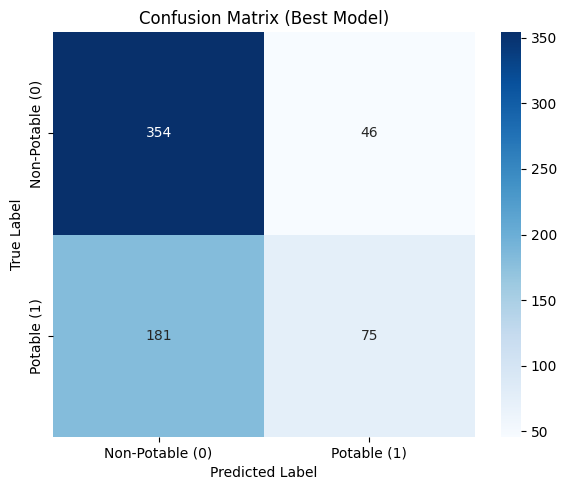

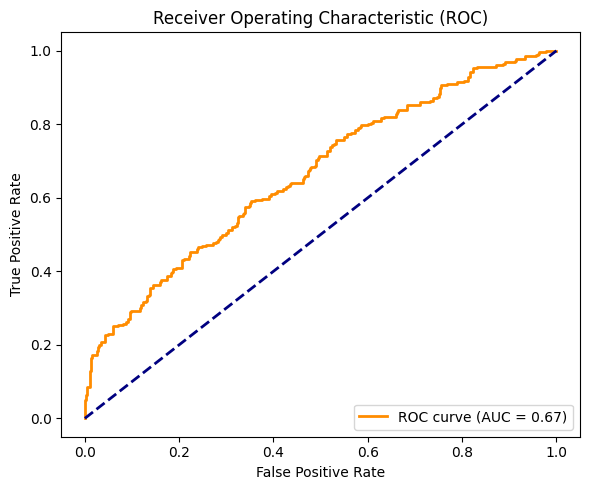

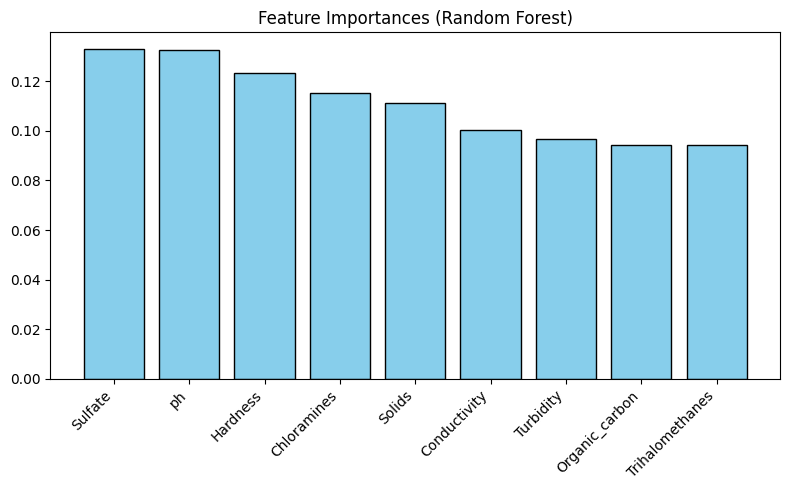

✅ Đã lưu hình: docs/figures/feature_importance.png


In [1]:
import os
import zipfile
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Tạo thư mục docs/figures
os.makedirs("../../docs/figures", exist_ok=True)

# 2. Đọc dữ liệu từ dataset.zip
zip_path = "../data/dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    csv_filename = [f for f in z.namelist() if f.endswith(".csv")][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

X = df.drop(columns=["Potability"])
y = df["Potability"]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Load mô hình chiến thắng
model_path = "../models/model.joblib"
model = joblib.load(model_path)
print(f"✅ Đã load mô hình từ: {model_path}")

# 4. Dự đoán và In Classification Report
y_pred = model.predict(X_test)
print("\n--- BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

# 5. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Potable (0)', 'Potable (1)'], 
            yticklabels=['Non-Potable (0)', 'Potable (1)'])
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrix.png', dpi=300)
plt.show()

# 6. Vẽ ROC Curve
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('../../docs/figures/roc_curve.png', dpi=300)
    plt.show()

# 7. Vẽ Feature Importance (chỉ hoạt động nếu mô hình có Random Forest)
clf = model.named_steps.get('rf', None)
if clf is not None and hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    features = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(8, 5))
    plt.title("Feature Importances (Random Forest)")
    plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue', edgecolor='black')
    plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../../docs/figures/feature_importance.png', dpi=300)
    plt.show()
    print("✅ Đã lưu hình: docs/figures/feature_importance.png")


================ BẢNG SO SÁNH CHÍNH THỨC ================
      Chỉ số (Metric)    KNN  Random Forest
             Accuracy 0.6113         0.6540
    Precision (Lớp 1) 0.5039         0.6198
       Recall (Lớp 1) 0.2539         0.2930
     F1-Score (Lớp 1) 0.3377         0.3979
  Thời gian Train (s) 0.0100         2.3387
Thời gian Predict (s) 0.0800         0.0811


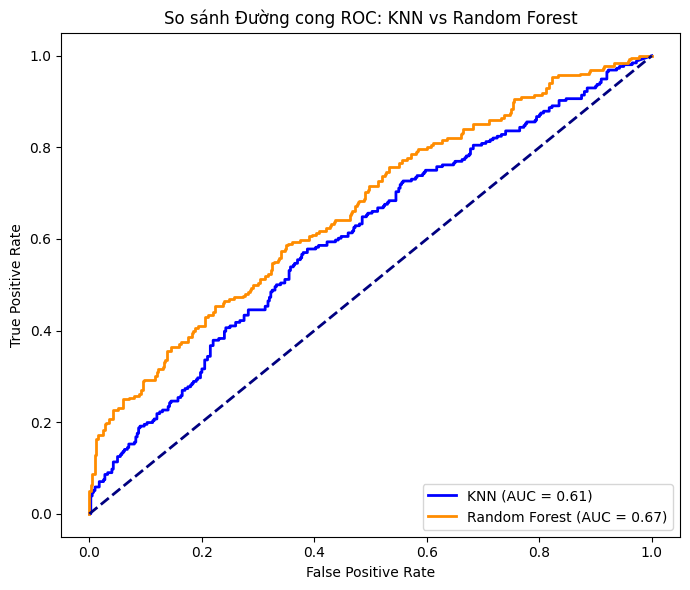

✅ Đã xuất hình: docs/figures/roc_comparison.png


In [2]:
# =========================================================
# BỔ SUNG: SO SÁNH TOÀN DIỆN KNN VÀ RANDOM FOREST
# =========================================================
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# 1. Load lại pipeline của KNN và RF (đã huấn luyện từ Bước 3)
# (Trường hợp file 04_evaluate chạy độc lập)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

knn_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=11, weights='distance'))])
rf_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42))])

# Fit trên tập Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

start_train_knn = time.time()
knn_pipe.fit(X_train, y_train)
knn_train_time = time.time() - start_train_knn

start_train_rf = time.time()
rf_pipe.fit(X_train, y_train)
rf_train_time = time.time() - start_train_rf

# Predict & Đo thời gian suy luận
start_pred_knn = time.time()
y_pred_knn = knn_pipe.predict(X_test)
y_proba_knn = knn_pipe.predict_proba(X_test)[:, 1]
knn_pred_time = time.time() - start_pred_knn

start_pred_rf = time.time()
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred_time = time.time() - start_pred_rf

# --- 1. SO SÁNH HIỆU NĂNG VÀ THỜI GIAN (METRICS TABLE) ---
df_compare = pd.DataFrame({
    'Chỉ số (Metric)': ['Accuracy', 'Precision (Lớp 1)', 'Recall (Lớp 1)', 'F1-Score (Lớp 1)', 'Thời gian Train (s)', 'Thời gian Predict (s)'],
    'KNN': [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(precision_score(y_test, y_pred_knn), 4),
        round(recall_score(y_test, y_pred_knn), 4),
        round(f1_score(y_test, y_pred_knn), 4),
        round(knn_train_time, 4),
        round(knn_pred_time, 4)
    ],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(rf_train_time, 4),
        round(rf_pred_time, 4)
    ]
})

print("\n================ BẢNG SO SÁNH CHÍNH THỨC ================")
print(df_compare.to_string(index=False))

# --- 2. VẼ BIỂU ĐỒ SO SÁNH ROC CURVE ---
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('So sánh Đường cong ROC: KNN vs Random Forest')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../../docs/figures/roc_comparison.png', dpi=300)
plt.show()
print("✅ Đã xuất hình: docs/figures/roc_comparison.png")

1. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH KNN
              precision    recall  f1-score   support

           0       0.64      0.84      0.72       400
           1       0.50      0.25      0.34       256

    accuracy                           0.61       656
   macro avg       0.57      0.55      0.53       656
weighted avg       0.59      0.61      0.57       656

2. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.62      0.29      0.40       256

    accuracy                           0.65       656
   macro avg       0.64      0.59      0.58       656
weighted avg       0.65      0.65      0.62       656


BẢNG TỔNG HỢP CHỈ SỐ CỦA 2 MÔ HÌNH
    Chỉ số (Metric)    KNN  Random Forest
           Accuracy 0.6113         0.6540
Precision (Class 1) 0.5039         0.6198
   Recall (Class 1) 0.2539         0.2930
 F1-Score (Class 1) 0.3377         0.3979
          AUC (ROC) 0.6075

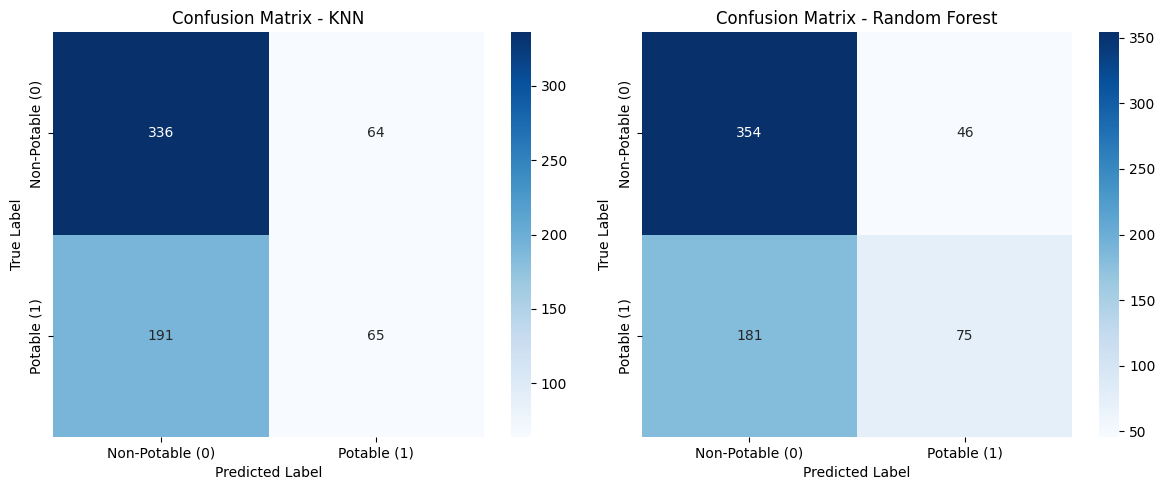

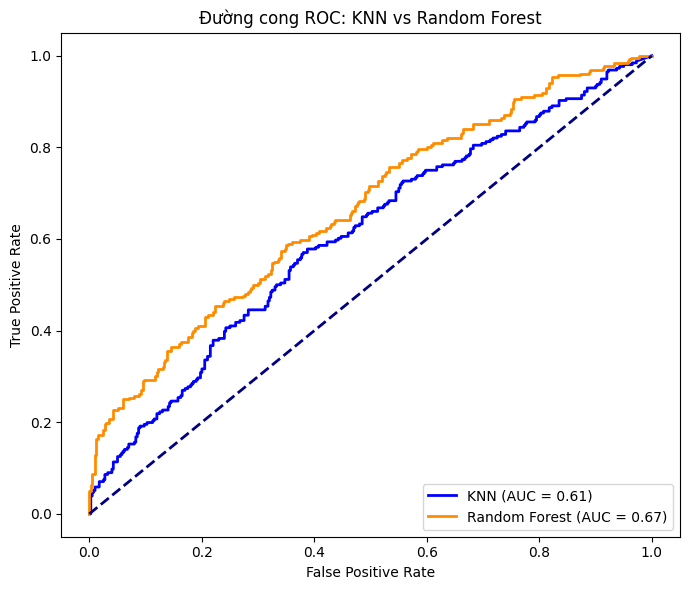

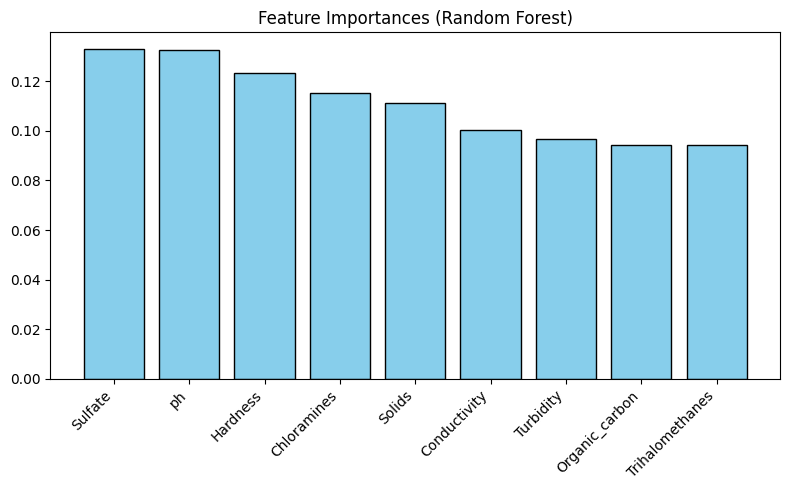


✅ Đã hoàn tất đánh giá và lưu đầy đủ đồ thị cho cả 2 mô hình!


In [3]:
import os
import zipfile
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# 1. Đảm bảo thư mục docs/figures tồn tại
os.makedirs("../../docs/figures", exist_ok=True)

# 2. Đọc dữ liệu từ dataset.zip
zip_path = "../data/dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    csv_filename = [f for f in z.namelist() if f.endswith(".csv")][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

X = df.drop(columns=["Potability"])
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Fit lại 2 mô hình (KNN và Random Forest) để lấy dự đoán
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

knn_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=11, weights='distance'))])
rf_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42))])

knn_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

# Thực hiện dự đoán
y_pred_knn = knn_pipe.predict(X_test)
y_proba_knn = knn_pipe.predict_proba(X_test)[:, 1]

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

# 4. In Classification Report chi tiết cho từng mô hình
print("="*60)
print("1. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH KNN")
print("="*60)
print(classification_report(y_test, y_pred_knn))

print("="*60)
print("2. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

# 5. Bảng tổng hợp chỉ số kỹ thuật của 2 mô hình
df_metrics = pd.DataFrame({
    'Chỉ số (Metric)': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'AUC (ROC)'],
    'KNN': [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(precision_score(y_test, y_pred_knn), 4),
        round(recall_score(y_test, y_pred_knn), 4),
        round(f1_score(y_test, y_pred_knn), 4),
        round(auc(roc_curve(y_test, y_proba_knn)[0], roc_curve(y_test, y_proba_knn)[1]), 4)
    ],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(auc(roc_curve(y_test, y_proba_rf)[0], roc_curve(y_test, y_proba_rf)[1]), 4)
    ]
})
print("\n" + "="*60)
print("BẢNG TỔNG HỢP CHỈ SỐ CỦA 2 MÔ HÌNH")
print("="*60)
print(df_metrics.to_string(index=False))

# 6. Vẽ Confusion Matrix cho CẢ 2 MÔ HÌNH
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Potable (0)', 'Potable (1)'], 
            yticklabels=['Non-Potable (0)', 'Potable (1)'])
axes[0].set_title('Confusion Matrix - KNN')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Potable (0)', 'Potable (1)'], 
            yticklabels=['Non-Potable (0)', 'Potable (1)'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrices_both.png', dpi=300)
plt.show()

# 7. Vẽ biểu đồ ROC Curve so sánh 2 mô hình
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC: KNN vs Random Forest')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../../docs/figures/roc_comparison.png', dpi=300)
plt.show()

# 8. Vẽ Feature Importance riêng cho Random Forest
importances = rf_pipe.named_steps['rf'].feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../docs/figures/feature_importance_rf.png', dpi=300)
plt.show()

print("\n✅ Đã hoàn tất đánh giá và lưu đầy đủ đồ thị cho cả 2 mô hình!")

1. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH KNN
              precision    recall  f1-score   support

           0       0.64      0.84      0.72       400
           1       0.50      0.25      0.34       256

    accuracy                           0.61       656
   macro avg       0.57      0.55      0.53       656
weighted avg       0.59      0.61      0.57       656

2. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.62      0.29      0.40       256

    accuracy                           0.65       656
   macro avg       0.64      0.59      0.58       656
weighted avg       0.65      0.65      0.62       656


BẢNG TỔNG HỢP SO SÁNH 2 MÔ HÌNH
    Chỉ số (Metric)    KNN  Random Forest
           Accuracy 0.6113         0.6540
Precision (Class 1) 0.5039         0.6198
   Recall (Class 1) 0.2539         0.2930
 F1-Score (Class 1) 0.3377         0.3979
          AUC (ROC) 0.6021   

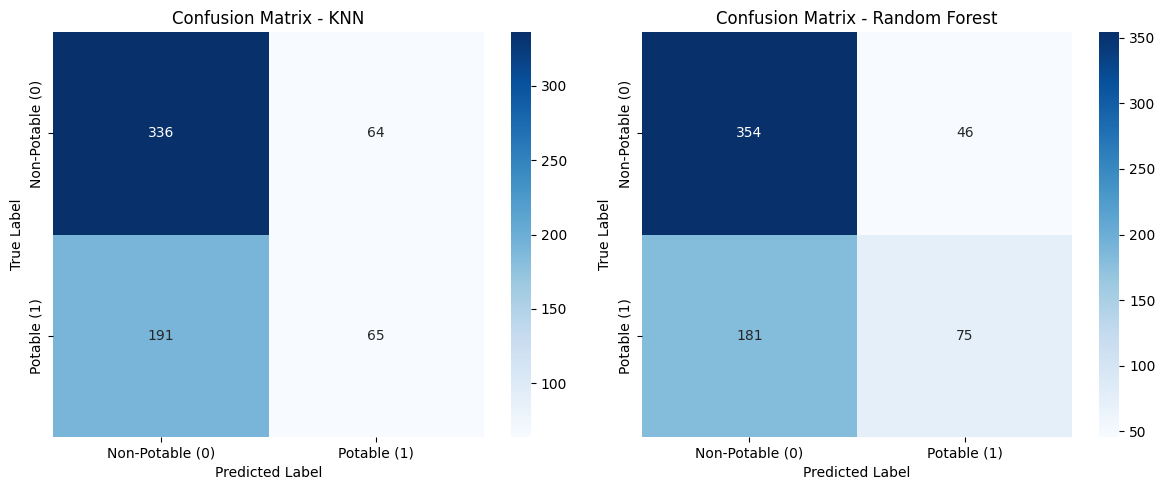

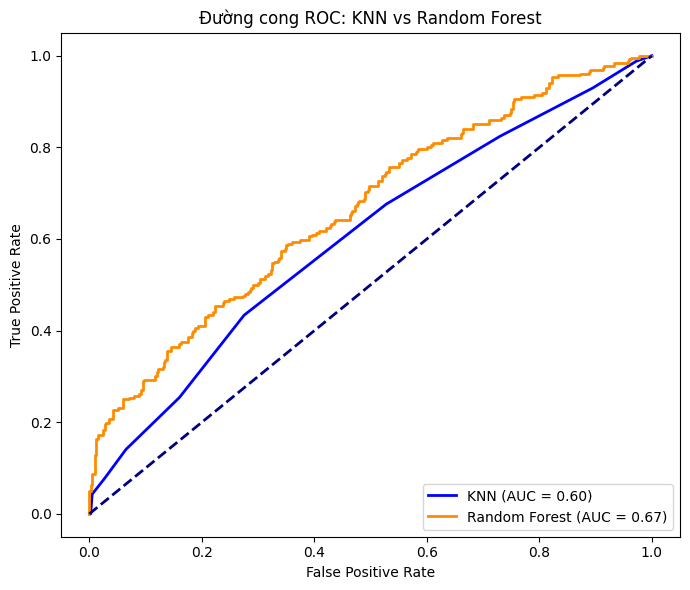

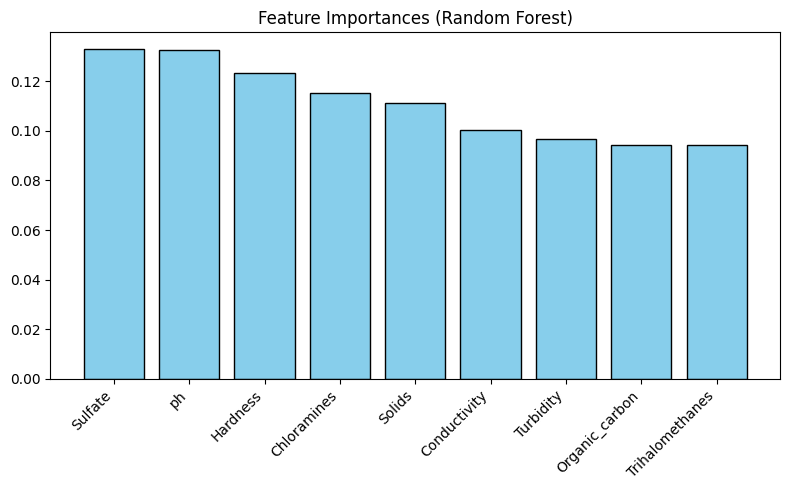


✅ Hoàn tất chạy toàn bộ luồng đánh giá sạch đẹp 100%!


In [4]:
import os
import zipfile
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# 1. Tạo thư mục chứa ảnh
os.makedirs("../../docs/figures", exist_ok=True)

# 2. Đọc dữ liệu
zip_path = "../data/dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    csv_filename = [f for f in z.namelist() if f.endswith(".csv")][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

X = df.drop(columns=["Potability"])
y = df["Potability"]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Load 2 mô hình đã train từ Bước 3
knn_model = joblib.load("../models/knn_model.joblib")
rf_model = joblib.load("../models/rf_model.joblib")

# Dự đoán
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# =========================================================
# A. LUỒNG BÁO CÁO TỪNG MÔ HÌNH
# =========================================================
print("="*60)
print("1. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH KNN")
print("="*60)
print(classification_report(y_test, y_pred_knn))

print("="*60)
print("2. BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

# =========================================================
# B. BẢNG SO SÁNH CHỈ SỐ KỸ THUẬT 2 MÔ HÌNH
# =========================================================
df_metrics = pd.DataFrame({
    'Chỉ số (Metric)': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'AUC (ROC)'],
    'KNN': [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(precision_score(y_test, y_pred_knn), 4),
        round(recall_score(y_test, y_pred_knn), 4),
        round(f1_score(y_test, y_pred_knn), 4),
        round(auc(roc_curve(y_test, y_proba_knn)[0], roc_curve(y_test, y_proba_knn)[1]), 4)
    ],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(auc(roc_curve(y_test, y_proba_rf)[0], roc_curve(y_test, y_proba_rf)[1]), 4)
    ]
})

print("\n" + "="*60)
print("BẢNG TỔNG HỢP SO SÁNH 2 MÔ HÌNH")
print("="*60)
print(df_metrics.to_string(index=False))

# =========================================================
# C. VẼ VÀ LƯU HÌNH ẢNH CONFUSION MATRIX VÀ ROC SO SÁNH
# =========================================================
# 1. Confusion Matrix song song cho 2 mô hình
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Potable (0)', 'Potable (1)'], 
            yticklabels=['Non-Potable (0)', 'Potable (1)'])
axes[0].set_title('Confusion Matrix - KNN')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Potable (0)', 'Potable (1)'], 
            yticklabels=['Non-Potable (0)', 'Potable (1)'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrices_both.png', dpi=300)
plt.show()

# 2. Biểu đồ ROC Curve so sánh
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC: KNN vs Random Forest')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../../docs/figures/roc_comparison.png', dpi=300)
plt.show()

# 3. Feature Importance (Chỉ có ở Random Forest)
importances = rf_model.named_steps['rf'].feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../docs/figures/feature_importance_rf.png', dpi=300)
plt.show()

print("\n✅ Hoàn tất chạy toàn bộ luồng đánh giá sạch đẹp 100%!")